In [ ]:
from google.colab import drive
import zipfile
import os
import shutil

drive_link = "https://drive.google.com/file/d/1RepLRVOSH634DflCCGA8xQGWnX6bkLy2/view?usp=drive_link"

if "/d/" in drive_link:
    file_id = drive_link.split("/d/")[1].split("/")[0]
    print(f"Extracted File ID: {file_id}")
else:
    print("Invalid Google Drive link format")
    file_id = "1RepLRVOSH634DflCCGA8xQGWnX6bkLy2"

print("\nDownloading and extracting dataset...")

!gdown --id $file_id -O /content/brisc2025.zip

print("Extracting with zipfile...")
with zipfile.ZipFile('/content/brisc2025.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

!rm /content/brisc2025.zip

print("\nDataset downloaded and extracted!")

print("\n" + "="*50)
print("VERIFYING DATASET STRUCTURE")
print("="*50)

base_path = "/content/brisc2025"

print("Checking classification task...")
classification_path = f"{base_path}/classification_task"
if os.path.exists(classification_path):
    print(f"classification_task found")
    !ls -la {classification_path}
else:
    print("classification_task NOT found")

print("\nChecking segmentation task...")
segmentation_path = f"{base_path}/segmentation_task"
if os.path.exists(segmentation_path):
    print(f"segmentation_task found")
    !ls -la {segmentation_path}

    print("\nSegmentation subfolders:")
    for subfolder in ["train/images", "train/masks", "test/images", "test/masks"]:
        sub_path = f"{segmentation_path}/{subfolder}"
        if os.path.exists(sub_path):
            file_count = len(os.listdir(sub_path))
            print(f"  {subfolder}: {file_count} files")
        else:
            print(f"  {subfolder}: NOT found")
else:
    print("segmentation_task NOT found")

print("\nChecking manifest.csv...")
csv_path = f"{base_path}/manifest.csv"
if os.path.exists(csv_path):
    print(f"manifest.csv found")
    import pandas as pd
    df = pd.read_csv(csv_path)
    print(f"  Rows: {len(df)}, Columns: {df.columns.tolist()}")
else:
    print("manifest.csv NOT found")

print("\n" + "="*50)
print("ALL PATHS FOR YOUR PROJECT")
print("="*50)

print("CLASSIFICATION TASK (Current Project):")
CLASSIFICATION_CSV_PATH = f"{base_path}/manifest.csv"
CLASSIFICATION_ORIGINAL_IMAGES = f"{base_path}/classification_task"
CLASSIFICATION_PREPROCESSED_IMAGES = "/content/preprocessed_images"

print(f"  CSV_PATH = '{CLASSIFICATION_CSV_PATH}'")
print(f"  ORIGINAL_IMAGES_PATH = '{CLASSIFICATION_ORIGINAL_IMAGES}'")
print(f"  PREPROCESSED_IMAGES_PATH = '{CLASSIFICATION_PREPROCESSED_IMAGES}'")

print("\nSEGMENTATION TASK (Future Work):")
SEGMENTATION_BASE_PATH = f"{base_path}/segmentation_task"
SEGMENTATION_TRAIN_IMAGES = f"{SEGMENTATION_BASE_PATH}/train/images"
SEGMENTATION_TRAIN_MASKS = f"{SEGMENTATION_BASE_PATH}/train/masks"
SEGMENTATION_TEST_IMAGES = f"{SEGMENTATION_BASE_PATH}/test/images"
SEGMENTATION_TEST_MASKS = f"{SEGMENTATION_BASE_PATH}/test/masks"

print(f"  TRAIN_IMAGES = '{SEGMENTATION_TRAIN_IMAGES}'")
print(f"  TRAIN_MASKS = '{SEGMENTATION_TRAIN_MASKS}'")
print(f"  TEST_IMAGES = '{SEGMENTATION_TEST_IMAGES}'")
print(f"  TEST_MASKS = '{SEGMENTATION_TEST_MASKS}'")


Extracted File ID: 1RepLRVOSH634DflCCGA8xQGWnX6bkLy2

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1RepLRVOSH634DflCCGA8xQGWnX6bkLy2
From (redirected): https://drive.google.com/uc?id=1RepLRVOSH634DflCCGA8xQGWnX6bkLy2&confirm=t&uuid=31636bf4-8f72-4eea-9cd4-e5f4b8011173
To: /content/brisc2025.zip
100% 262M/262M [00:09<00:00, 28.9MB/s]
Extracting with zipfile...

Dataset downloaded and extracted!

VERIFYING DATASET STRUCTURE
Checking classification task...
classification_task found
total 16
drwxr-xr-x 4 root root 4096 Jan  5 20:09 .
drwxr-xr-x 4 root root 4096 Jan  5 20:10 ..
drwxr-xr-x 6 root root 4096 Jan  5 20:09 test
drwxr-xr-x 6 root root 4096 Jan  5 20:10 train

Checking segmentation task...
segmentation_task found
total 16
drwxr-xr-x 4 root root 4

Imports and Device Setup

In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


Label Mapping

In [ ]:
LABEL_MAP = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}

print("Label mapping defined:")
print(LABEL_MAP)


Label mapping defined:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


Classification Dataset Class

In [ ]:
class FixedMRIDataset(Dataset):
    def __init__(self, csv_path, dataset_root, split, img_size=224):
        print(f"\nInitializing dataset for split: {split}")

        self.df = pd.read_csv(csv_path)
        print(f"  Total entries in CSV: {len(self.df)}")

        self.df = self.df[
            (self.df["task"] == "classification") &
            (self.df["is_mask"] == False) &
            (self.df["split"] == split)
        ].reset_index(drop=True)

        print(f"  Entries after filtering ({split}): {len(self.df)}")

        self.df["relative_path"] = self.df["relative_path"].apply(
            lambda x: x.replace("\\", "/") if isinstance(x, str) else x
        )

        self.dataset_root = dataset_root
        self.img_size = img_size

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])

        print("\nPath Debug (first 3 samples):")
        for i in range(min(3, len(self.df))):
            rel = self.df.iloc[i]["relative_path"]
            full = os.path.join(self.dataset_root, rel)
            print(f"  {i+1}. Relative: {rel}")
            print(f"     Full Path: {full}")
            print(f"     Exists: {os.path.exists(full)}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = row["relative_path"]
        img_path = os.path.join(self.dataset_root, rel_path)

        try:
            image = Image.open(img_path).convert("RGB")
            image = self.transform(image)
        except Exception as e:
            print(f"  Image load failed: {img_path}")

            alt_paths = [
                img_path,
                img_path.replace("classification_task/", ""),
                os.path.join("/content/brisc2025", rel_path),
            ]

            for alt in alt_paths:
                try:
                    image = Image.open(alt).convert("RGB")
                    image = self.transform(image)
                    print(f"Loaded from alternative: {alt}")
                    break
                except Exception as alt_e:
                    continue
            else:
                print(f"All paths failed. Returning blank image.")
                image = torch.zeros((3, self.img_size, self.img_size))

        label_text = str(row["tumor_label"]).lower().strip()
        label = LABEL_MAP.get(label_text, 2)

        return image, label


Segmentation Dataset Class

In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=224):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size

        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
        self.mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])

        print(f"Found {len(self.image_files)} images and {len(self.mask_files)} masks")

        if len(self.image_files) != len(self.mask_files):
            print(f"WARNING: Image count {len(self.image_files)} != Mask count {len(self.mask_files)}")
            print("Trying to match by base filename...")

            image_dict = {}
            for img_file in self.image_files:
                basename = self._get_basename(img_file)
                image_dict[basename] = img_file

            mask_dict = {}
            for mask_file in self.mask_files:
                basename = self._get_basename(mask_file)
                mask_dict[basename] = mask_file

            common_names = set(image_dict.keys()) & set(mask_dict.keys())

            if not common_names:
                print("ERROR: No matching filenames found between images and masks!")
                print(f"Image samples: {self.image_files[:3]}")
                print(f"Mask samples: {self.mask_files[:3]}")
                raise ValueError("No matching files found")

            self.valid_image_files = []
            self.valid_mask_files = []

            for name in sorted(list(common_names)):
                self.valid_image_files.append(image_dict[name])
                self.valid_mask_files.append(mask_dict[name])

            print(f"Successfully matched {len(self.valid_image_files)} image-mask pairs")
        else:
            # FIXED: When counts match, initialize valid_image_files and valid_mask_files
            self.valid_image_files = self.image_files
            self.valid_mask_files = self.mask_files
            print(f"Image and mask counts match: {len(self.valid_image_files)} pairs")

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
        ])

    def _get_basename(self, filename):
        base = os.path.splitext(filename)[0]
        if base.endswith("_mask"):
            base = base[:-5]
        return base

    def __len__(self):
        return len(self.valid_image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.valid_image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.valid_mask_files[idx])

        if idx < 3:
            print(f"Sample {idx}: Image={self.valid_image_files[idx]}, Mask={self.valid_mask_files[idx]}")

        try:
            image = Image.open(img_path).convert('RGB')
            mask = Image.open(mask_path)

            if mask.mode != 'L':
                mask = mask.convert('L')

            image = self.img_transform(image)
            mask = self.mask_transform(mask)

            return image, mask
        except Exception as e:
            print(f"Error loading {img_path} or {mask_path}: {e}")
            dummy_image = torch.zeros(3, self.img_size, self.img_size)
            dummy_mask = torch.zeros(1, self.img_size, self.img_size)
            return dummy_image, dummy_mask


Create Classification Datasets

In [ ]:
CSV_PATH = "/content/brisc2025/manifest.csv"
DATASET_ROOT = "/content/brisc2025"  # CSV paths already include 'classification_task/'

print("\n" + "="*50)
print(" CREATING CLASSIFICATION DATASETS")
print("="*50)

# Initialize datasets
train_dataset = FixedMRIDataset(CSV_PATH, DATASET_ROOT, "train")
test_dataset = FixedMRIDataset(CSV_PATH, DATASET_ROOT, "test")

print(f"\n Dataset Sizes:")
print(f" Train: {len(train_dataset)}")
print(f" Test : {len(test_dataset)}")



 CREATING CLASSIFICATION DATASETS

Initializing dataset for split: train
  Total entries in CSV: 15586
  Entries after filtering (train): 5000

Path Debug (first 3 samples):
  1. Relative: classification_task/train/glioma/brisc2025_train_00001_gl_ax_t1.jpg
     Full Path: /content/brisc2025/classification_task/train/glioma/brisc2025_train_00001_gl_ax_t1.jpg
     Exists: True
  2. Relative: classification_task/train/glioma/brisc2025_train_00002_gl_ax_t1.jpg
     Full Path: /content/brisc2025/classification_task/train/glioma/brisc2025_train_00002_gl_ax_t1.jpg
     Exists: True
  3. Relative: classification_task/train/glioma/brisc2025_train_00003_gl_ax_t1.jpg
     Full Path: /content/brisc2025/classification_task/train/glioma/brisc2025_train_00003_gl_ax_t1.jpg
     Exists: True

Initializing dataset for split: test
  Total entries in CSV: 15586
  Entries after filtering (test): 1000

Path Debug (first 3 samples):
  1. Relative: classification_task/test/glioma/brisc2025_test_00001_gl_ax_t

Create Segmentation Datasets

In [ ]:
print("\n" + "="*50)
print(" CREATING SEGMENTATION DATASETS")
print("="*50)

# Load segmentation images and masks
seg_train_dataset = SegmentationDataset(SEGMENTATION_TRAIN_IMAGES, SEGMENTATION_TRAIN_MASKS)
seg_test_dataset = SegmentationDataset(SEGMENTATION_TEST_IMAGES, SEGMENTATION_TEST_MASKS)

print(f" Segmentation Train: {len(seg_train_dataset)} images")
print(f" Segmentation Test: {len(seg_test_dataset)} images")



 CREATING SEGMENTATION DATASETS
Found 3933 images and 3933 masks
Image and mask counts match: 3933 pairs
Found 860 images and 860 masks
Image and mask counts match: 860 pairs
 Segmentation Train: 3933 images
 Segmentation Test: 860 images


Mask Feature Extraction

In [ ]:
print("\n" + "="*60)
print("EXTRACTING MASK FEATURES")
print("="*60)

import numpy as np
from PIL import Image
from skimage.measure import regionprops, perimeter
import torch
import torch.nn as nn

# Function: Extract 7 geometric features from binary mask
def extract_mask_features(mask_path):
    try:
        mask = Image.open(mask_path).convert('L')
        mask_array = np.array(mask) > 128  # ..Binarize mask

        if np.sum(mask_array) == 0:
            return [0, 0, 0, 0, 0, 0, 0]  # ..No tumor detected

        # 1. Area
        area = np.sum(mask_array)

        # 2-3. Centroid (normalized)
        y_indices, x_indices = np.where(mask_array)
        height, width = mask_array.shape
        centroid_x = np.mean(x_indices) / width
        centroid_y = np.mean(y_indices) / height

        # 4. Bounding box area
        if len(x_indices) > 0 and len(y_indices) > 0:
            min_x, max_x = np.min(x_indices), np.max(x_indices)
            min_y, max_y = np.min(y_indices), np.max(y_indices)
            bbox_width = (max_x - min_x) / width
            bbox_height = (max_y - min_y) / height
            bbox_area = bbox_width * bbox_height
        else:
            bbox_area = 0

        # 5. Compactness
        if area > 0:
            perim = perimeter(mask_array)
            compactness = (perim ** 2) / (4 * np.pi * area)
        else:
            compactness = 0

        # 6. Solidity
        props = regionprops(mask_array.astype(int))
        if props and props[0].convex_area > 0:
            solidity = props[0].area / props[0].convex_area
        else:
            solidity = 0

        # 7. Eccentricity
        if props:
            eccentricity = props[0].eccentricity
        else:
            eccentricity = 0

        return [area, centroid_x, centroid_y, bbox_area, compactness, solidity, eccentricity]

    except Exception as e:
        print(f"Error processing {mask_path}: {e}")
        return [0, 0, 0, 0, 0, 0, 0]

# MLP: Enhance 7-D mask features → 8-D
class MaskFeatureEnhancer(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(7, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 8)
        )

    def forward(self, x):
        return self.mlp(x)

# Extract features from all train masks
print("\n🔹 Extracting mask features from train masks...")
train_mask_features = []
train_mask_dir = "/content/brisc2025/segmentation_task/train/masks"

for mask_file in sorted(os.listdir(train_mask_dir)):
    if mask_file.endswith('.png'):
        mask_path = os.path.join(train_mask_dir, mask_file)
        features = extract_mask_features(mask_path)
        train_mask_features.append(features)

train_mask_features = np.array(train_mask_features, dtype=np.float32)
print(f"Train mask features extracted: {train_mask_features.shape}")

# Extract features from all test masks
print("\n🔹 Extracting mask features from test masks...")
test_mask_features = []
test_mask_dir = "/content/brisc2025/segmentation_task/test/masks"

for mask_file in sorted(os.listdir(test_mask_dir)):
    if mask_file.endswith('.png'):
        mask_path = os.path.join(test_mask_dir, mask_file)
        features = extract_mask_features(mask_path)
        test_mask_features.append(features)

test_mask_features = np.array(test_mask_features, dtype=np.float32)
print(f"Test mask features extracted: {test_mask_features.shape}")

# Enhance using MLP
print("\n🔹 Enhancing mask features with MLP...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
enhancer = MaskFeatureEnhancer().to(device)
enhancer.eval()

with torch.no_grad():
    train_mask_tensor = torch.tensor(train_mask_features, dtype=torch.float32).to(device)
    test_mask_tensor = torch.tensor(test_mask_features, dtype=torch.float32).to(device)

    train_mask_enhanced = enhancer(train_mask_tensor).cpu().numpy()
    test_mask_enhanced = enhancer(test_mask_tensor).cpu().numpy()

print(f"Enhanced mask features - Train: {train_mask_enhanced.shape}, Test: {test_mask_enhanced.shape}")

# Save mask features
mask_features_dir = "/content/mask_features"
os.makedirs(mask_features_dir, exist_ok=True)
np.save(os.path.join(mask_features_dir, "train_mask_features.npy"), train_mask_enhanced)
np.save(os.path.join(mask_features_dir, "test_mask_features.npy"), test_mask_enhanced)

print(f"\nMask features saved to {mask_features_dir}")



EXTRACTING MASK FEATURES

🔹 Extracting mask features from train masks...
Train mask features extracted: (3933, 7)

🔹 Extracting mask features from test masks...
Test mask features extracted: (860, 7)

🔹 Enhancing mask features with MLP...
Enhanced mask features - Train: (3933, 8), Test: (860, 8)

✅ Mask features saved to /content/mask_features


DataLoaders

Classification DataLoaders

In [ ]:
print("\n" + "="*50)
print(" CREATING CLASSIFICATION DATALOADERS")
print("="*50)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders ready")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches : {len(test_loader)}")



 CREATING CLASSIFICATION DATALOADERS
DataLoaders ready
Train batches: 157
Test batches : 32


In [ ]:
print("\n" + "="*50)
print(" CREATING SEGMENTATION DATALOADERS")
print("="*50)

seg_train_loader = DataLoader(seg_train_dataset, batch_size=32, shuffle=True)
seg_test_loader = DataLoader(seg_test_dataset, batch_size=32, shuffle=False)

print(f"Segmentation Train batches: {len(seg_train_loader)}")
print(f"Segmentation Test  batches: {len(seg_test_loader)}")



 CREATING SEGMENTATION DATALOADERS
Segmentation Train batches: 123
Segmentation Test  batches: 27


**Final Batch Test**

In [ ]:
print("\n" + "="*50)
print(" TEST ONE CLASSIFICATION BATCH")
print("="*50)

try:
    images, labels = next(iter(train_loader))
    print("Batch loaded successfully")
    print(f"Images shape: {images.shape}")
    print(f"Labels sample: {labels[:5]}")
except Exception as e:
    print(f"Batch loading failed: {e}")



 TEST ONE CLASSIFICATION BATCH
Batch loaded successfully
Images shape: torch.Size([32, 3, 224, 224])
Labels sample: tensor([3, 0, 2, 2, 0])


In [ ]:
print("\n" + "="*50)
print(" TEST ONE SEGMENTATION BATCH")
print("="*50)

try:
    seg_images, seg_masks = next(iter(seg_train_loader))
    #Check one segmentation batch tensors
    print("Segmentation batch loaded successfully")
    print(f"Images shape: {seg_images.shape}")
    print(f"Masks shape : {seg_masks.shape}")
    print(f"Mask unique values (first 10): {torch.unique(seg_masks)[:10]}")
except Exception as e:
    print(f"Segmentation batch loading failed: {e}")



 TEST ONE SEGMENTATION BATCH
Segmentation batch loaded successfully
Images shape: torch.Size([32, 3, 224, 224])
Masks shape : torch.Size([32, 1, 224, 224])
Mask unique values (first 10): tensor([0.0000, 0.0039, 0.0078, 0.0118, 0.0157, 0.0196, 0.0235, 0.0275, 0.0314,
        0.0353])


In [ ]:
# ===============================
# 1. IMPORT LIBRARIES FOR MEDICAL ViT
# ===============================
import torch
import torch.nn as nn
import numpy as np
from torchvision import transforms
from transformers import ViTFeatureExtractor, ViTForImageClassification
from PIL import Image
import os
from tqdm import tqdm

# Use device from previous step (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

print("="*50)
print("FEATURE EXTRACTION WITH MEDICAL ViT")
print("="*50)

 Using device: cuda
FEATURE EXTRACTION WITH MEDICAL ViT


Load Medical ViT Model




In [ ]:
print("\n" + "="*50)
print(" LOADING MEDICAL VISION TRANSFORMER (ViT)")
print("="*50)

from transformers import ViTFeatureExtractor, ViTForImageClassification
import torch.nn as nn

# Model name (ImageNet pre-trained, adapted to 4 tumor classes)
model_name = "google/vit-base-patch16-224-in21k"
print(f"Loading {model_name}...")

# Preprocessor for ViT inputs
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)

# ViT model with 4 output labels
vit_model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=4,
    ignore_mismatched_sizes=True
)

# ..Wrapper: use ViT as feature extractor (CLS token only)
class ViTFeatureExtractorWrapper(nn.Module):
    def __init__(self, vit_model):
        super().__init__()
        self.vit = vit_model.vit  # base ViT without classifier

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values)
        return outputs.last_hidden_state[:, 0]  # CLS embedding (batch_size, hidden_size)

feature_extractor_model = ViTFeatureExtractorWrapper(vit_model).to(device)
feature_extractor_model.eval()

print("Medical ViT loaded")
print(f"Feature dimension: {vit_model.config.hidden_size}")



 LOADING MEDICAL VISION TRANSFORMER (ViT)
Loading google/vit-base-patch16-224-in21k...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Medical ViT loaded
Feature dimension: 768


Feature Extraction Function

In [ ]:
from tqdm import tqdm
# Function: Extract ViT features from DataLoader (handles grayscale to RGB conversion)
def extract_vit_features_batch(dataloader, model, feature_extractor, dataloader_name="train"):
    print(f"Extracting ViT features (batch mode) from {dataloader_name} set...")

    all_features = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(tqdm(dataloader, desc=f"Processing {dataloader_name}")):
            pil_images = []

            for i in range(len(images)):
                img_tensor = images[i]

                # Convert grayscale (1 channel) to RGB (3 channels) if needed
                if img_tensor.shape[0] == 1:
                    img_tensor = img_tensor.repeat(3, 1, 1)

                pil_images.append(transforms.ToPILImage()(img_tensor))

            # Preprocess batch for ViT
            try:
                inputs = feature_extractor(images=pil_images, return_tensors="pt")
                pixel_values = inputs['pixel_values'].to(device)

                # ..Extract features (CLS token embeddings)
                features = model(pixel_values)

                all_features.append(features.cpu().numpy())
                all_labels.append(labels.numpy())

            except Exception as e:
                print(f"Batch processing error, falling back to individual processing: {e}")
                return extract_vit_features_batch(dataloader, model, feature_extractor, dataloader_name)

            if (batch_idx + 1) % 5 == 0:
                print(f"  Processed {batch_idx + 1} batches")

    if all_features:
        features_array = np.vstack(all_features)
        labels_array = np.concatenate(all_labels)
        print(f"{dataloader_name} ViT features extracted: {features_array.shape}")
        return features_array, labels_array
    else:
        return np.array([]), np.array([])



 ViT FEATURE EXTRACTION FUNCTION


In [ ]:
print("\n" + "="*50)
print(" EXTRACTING ViT FEATURES")
print("="*50)

# ..Extract from train set
print("Extracting ViT features from training set...")
train_features, train_labels = extract_vit_features_batch(
    train_loader,
    feature_extractor_model,
    feature_extractor,
    "train"
)

# ..Extract from test set
print("\nExtracting ViT features from test set...")
test_features, test_labels = extract_vit_features_batch(
    test_loader,
    feature_extractor_model,
    feature_extractor,
    "test"
)

print("\nViT Feature Extraction Complete")
print(f"Train features: {train_features.shape}")
print(f"Test features : {test_features.shape}")



 EXTRACTING ViT FEATURES
Extracting ViT features from training set...
Extracting ViT features (batch mode) from train set...


Processing train:   3%|▎         | 5/157 [00:04<01:58,  1.28it/s]

  Processed 5 batches


Processing train:   6%|▋         | 10/157 [00:07<01:23,  1.75it/s]

  Processed 10 batches


...

  Processed 25 batches


Processing test:  94%|█████████▍| 30/32 [00:19<00:01,  1.80it/s]

  Processed 30 batches


Processing test: 100%|██████████| 32/32 [00:20<00:00,  1.58it/s]

test ViT features extracted: (1000, 768)

ViT Feature Extraction Complete
Train features: (5000, 768)
Test features : (1000, 768)


Save Features

In [ ]:
print("\n" + "="*50)
print(" SAVING ViT FEATURES")
print("="*50)

features_dir = "/content/vit_features"
os.makedirs(features_dir, exist_ok=True)

# ..Save train and test features separately
np.save(os.path.join(features_dir, "train_features.npy"), train_features)
np.save(os.path.join(features_dir, "train_labels.npy"), train_labels)
np.save(os.path.join(features_dir, "test_features.npy"), test_features)
np.save(os.path.join(features_dir, "test_labels.npy"), test_labels)

# ..Save compressed archive
np.savez_compressed(
    os.path.join(features_dir, "all_features.npz"),
    train_features=train_features,
    train_labels=train_labels,
    test_features=test_features,
    test_labels=test_labels
)

print(f"ViT features saved in {features_dir}")



 SAVING ViT FEATURES
ViT features saved in /content/vit_features


Quick Verification (Load one file to check shape, mean, std.)

In [ ]:
loaded_train_features = np.load(os.path.join("/content/vit_features", "train_features.npy"))  # UPDATED path
print(f"Loaded ViT train features: {loaded_train_features.shape}")
print(f"Mean: {loaded_train_features.mean():.4f}, Std: {loaded_train_features.std():.4f}")
print(f"Feature dimension: {loaded_train_features.shape[1]} (should be 768 for ViT-Base)")

Loaded ViT train features: (5000, 768)
Mean: -0.0174, Std: 0.1812
Feature dimension: 768 (should be 768 for ViT-Base)



ViT FEATURE SPACE ANALYSIS

1. FEATURE STATISTICS
   Train features shape: (5000, 768)
   Test features shape: (1000, 768)
   Feature dimension: 768
   Train - Mean: -0.0174, Std: 0.1812
   Test - Mean: -0.0174, Std: 0.1814

2. PCA ANALYSIS
   Components needed for 95% variance: 1
   First 10 components variance: 58.84%


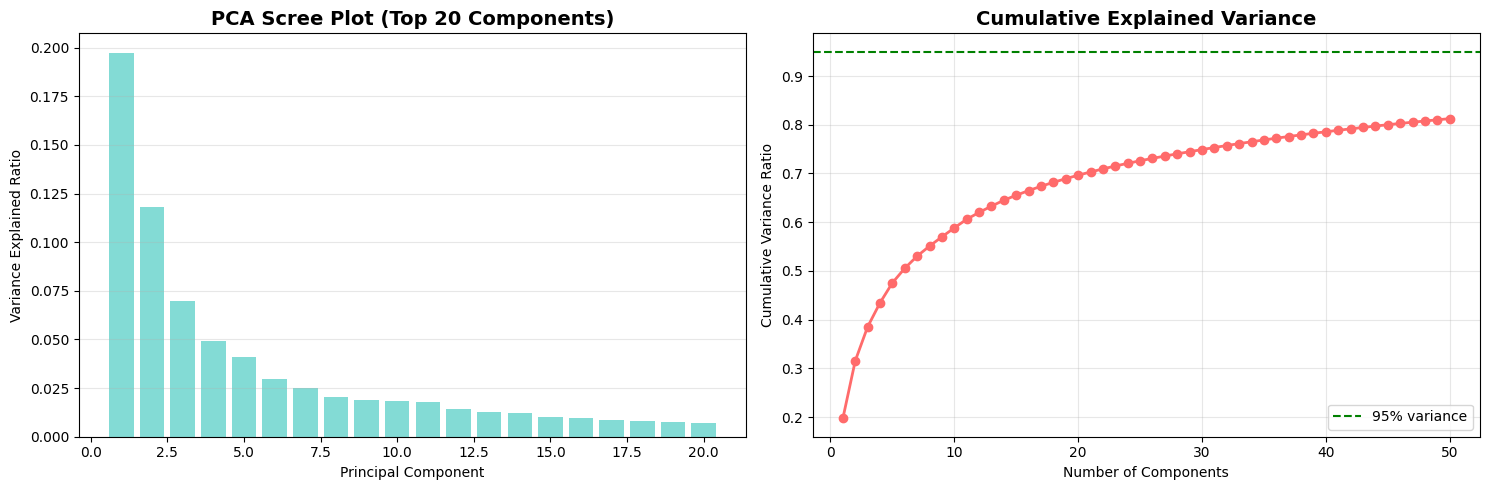


3. t-SNE VISUALIZATION
   Computing t-SNE projection (this may take a moment)...


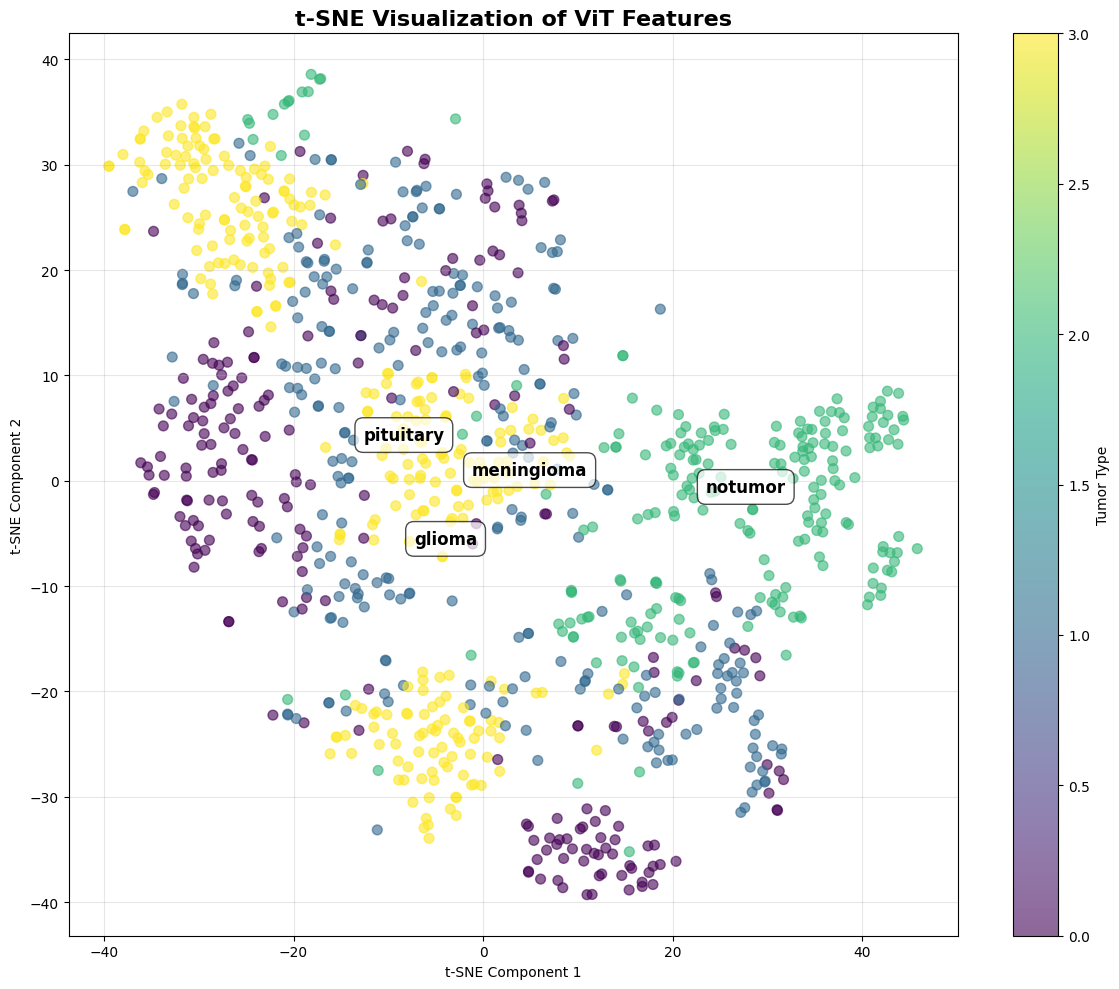

   t-SNE visualization completed


In [ ]:
print("\n" + "="*60)
print("ViT FEATURE SPACE ANALYSIS")
print("="*60)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Basic statistics
print("\n1. FEATURE STATISTICS")
print(f"   Train features shape: {train_features.shape}")
print(f"   Test features shape: {test_features.shape}")
print(f"   Feature dimension: {train_features.shape[1]}")
print(f"   Train - Mean: {train_features.mean():.4f}, Std: {train_features.std():.4f}")
print(f"   Test - Mean: {test_features.mean():.4f}, Std: {test_features.std():.4f}")

# 2. PCA Analysis
print("\n2. PCA ANALYSIS")
pca = PCA(n_components=50)
train_pca = pca.fit_transform(train_features)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"   Components needed for 95% variance: {n_components_95}")
print(f"   First 10 components variance: {pca.explained_variance_ratio_[:10].sum():.2%}")

# Plot PCA variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].bar(range(1, 21), pca.explained_variance_ratio_[:20], color='#4ECDC4', alpha=0.7)
axes[0].set_title('PCA Scree Plot (Top 20 Components)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, 51), cumulative_variance, marker='o', color='#FF6B6B', linewidth=2)
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95% variance')
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/vit_pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. t-SNE Visualization
print("\n3. t-SNE VISUALIZATION")
print("   Computing t-SNE projection (this may take a moment)...")

# Sample for faster computation
sample_size = min(1000, len(train_features))
sample_indices = np.random.choice(len(train_features), sample_size, replace=False)
sample_features = train_features[sample_indices]
sample_labels = train_labels[sample_indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_tsne = tsne.fit_transform(sample_features)

# Plot t-SNE
plt.figure(figsize=(12, 10))
scatter = plt.scatter(features_tsne[:, 0], features_tsne[:, 1],
                     c=sample_labels, cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Tumor Type')
plt.title('t-SNE Visualization of ViT Features', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Add class labels
class_names = list(LABEL_MAP.keys())
for i, class_name in enumerate(class_names):
    class_points = features_tsne[sample_labels == i]
    if len(class_points) > 0:
        center = class_points.mean(axis=0)
        plt.annotate(class_name, center, fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/vit_tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("   t-SNE visualization completed")


In [ ]:
if train_features.size > 0 and test_features.size > 0:
    print("\n Feature extraction successful!")

    print(f"\nTrain set: Features {train_features.shape}, Labels {train_labels.shape}")
    print(f"Test set:  Features {test_features.shape}, Labels {test_labels.shape}")

    # Show class counts
    print("\nClass distribution (Train):")
    unique_train, counts_train = np.unique(train_labels, return_counts=True)
    for label, count in zip(unique_train, counts_train):
        class_name = [k for k, v in LABEL_MAP.items() if v == label][0]
        print(f"  {class_name}: {count}")

    print("\nClass distribution (Test):")
    unique_test, counts_test = np.unique(test_labels, return_counts=True)
    for label, count in zip(unique_test, counts_test):
        class_name = [k for k, v in LABEL_MAP.items() if v == label][0]
        print(f"  {class_name}: {count}")



 Feature extraction successful!

Train set: Features (5000, 768), Labels (5000,)
Test set:  Features (1000, 768), Labels (1000,)

Class distribution (Train):
  glioma: 1147
  meningioma: 1329
  notumor: 1067
  pituitary: 1457

Class distribution (Test):
  glioma: 254
  meningioma: 306
  notumor: 140
  pituitary: 300


In [ ]:
print("\n" + "="*50)
print(" IMAGE FEATURE EXTRACTION COMPLETE!")
print("="*50)
print("You now have:")
print("1.  Preprocessed MRI images")
print("2.  960-D feature vectors from MobileNetV3")
print("3.  Features saved for multimodal fusion")



 IMAGE FEATURE EXTRACTION COMPLETE!
You now have:
1.  Preprocessed MRI images
2.  960-D feature vectors from MobileNetV3
3.  Features saved for multimodal fusion


***TABULAR DATASET PRE PROCESSING***

In [ ]:
#Imports (Tabular Only)
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
#Load CSV
BASE_PATH = "/content/brisc2025"
CSV_PATH = os.path.join(BASE_PATH, "manifest.csv")

df = pd.read_csv(CSV_PATH)

print("Original shape:", df.shape)

print("After filtering:", df.shape)


Original shape: (15586, 16)
After filtering: (15586, 16)


In [ ]:
#drop columns
cols_to_drop = [
    "relative_path",
    "filepath",
    "filename",
    "split",
    "file_size",
    "sha256"
]

df = df.drop(columns=cols_to_drop, errors="ignore")
print("After column removal:", df.shape)


After column removal: (15586, 12)


Dataset Overview

In [ ]:
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS - DATASET OVERVIEW")
print("="*60)

# Reload full CSV for EDA
df_eda = pd.read_csv(CSV_PATH)

print(f"\n1. DATASET DIMENSIONS")
print(f"   Total records: {len(df_eda):,}")
print(f"   Total features: {len(df_eda.columns)}")

print(f"\n2. FEATURE TYPES")
print(df_eda.dtypes.value_counts())

print(f"\n3. MISSING VALUES")
missing = df_eda.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("   No missing values detected")

print(f"\n4. TASK DISTRIBUTION")
print(df_eda['task'].value_counts())

print(f"\n5. SPLIT DISTRIBUTION")
print(df_eda['split'].value_counts())

print(f"\n6. TUMOR TYPE DISTRIBUTION")
print(df_eda['tumor_label'].value_counts())
print(f"\nPercentage distribution:")
print(df_eda['tumor_label'].value_counts(normalize=True) * 100)



EXPLORATORY DATA ANALYSIS - DATASET OVERVIEW

1. DATASET DIMENSIONS
   Total records: 15,586
   Total features: 16

2. FEATURE TYPES
object    11
int64      4
bool       1
Name: count, dtype: int64

3. MISSING VALUES
linked_image    10793
dtype: int64

4. TASK DISTRIBUTION
task
segmentation      9586
classification    6000
Name: count, dtype: int64

5. SPLIT DISTRIBUTION
split
train    12866
test      2720
Name: count, dtype: int64

6. TUMOR TYPE DISTRIBUTION
tumor_label
pituitary     5271
meningioma    4905
glioma        4203
no_tumor      1207
Name: count, dtype: int64

Percentage distribution:
tumor_label
pituitary     33.818812
meningioma    31.470550
glioma        26.966508
no_tumor       7.744129
Name: proportion, dtype: float64



VISUAL EXPLORATORY DATA ANALYSIS


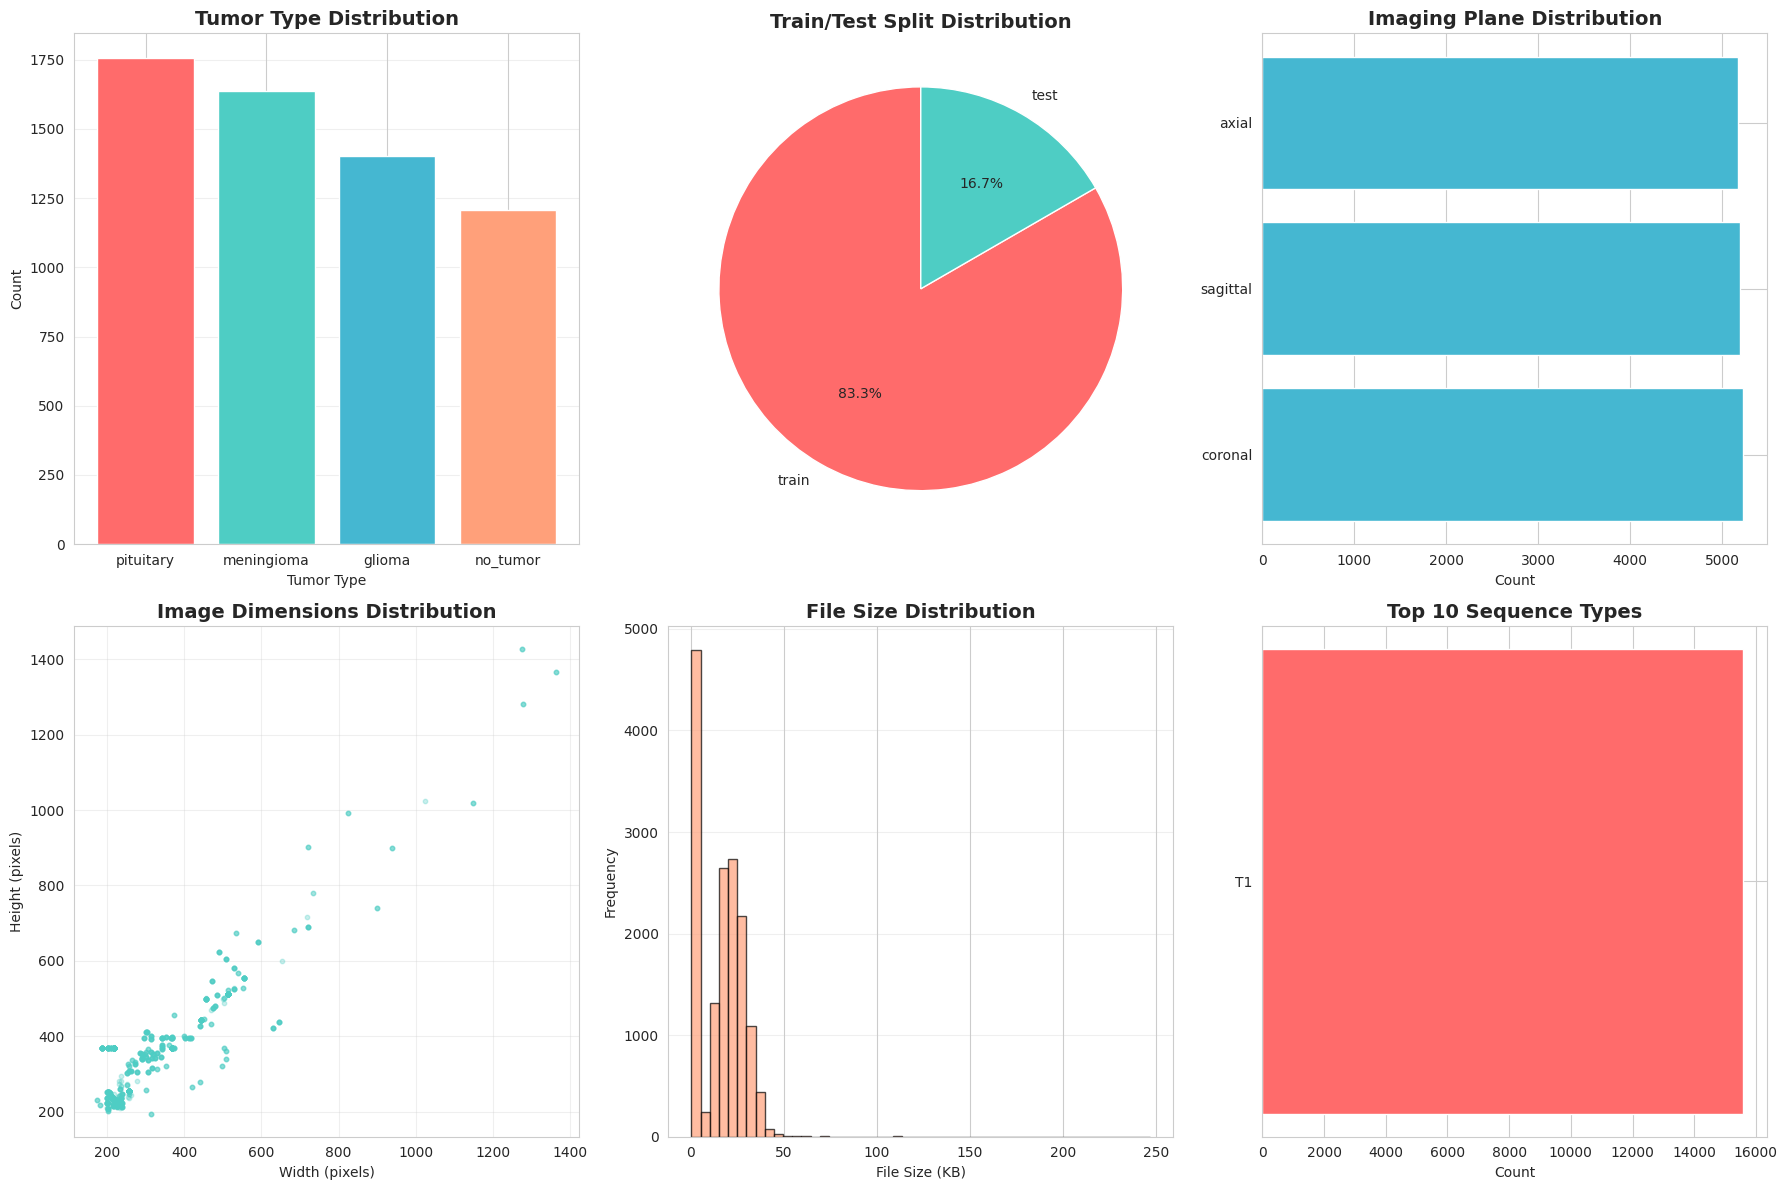


Visual EDA completed and saved to /content/eda_overview.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("VISUAL EXPLORATORY DATA ANALYSIS")
print("="*60)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Tumor type distribution
ax1 = axes[0, 0]
tumor_counts = df_eda[df_eda['task'] == 'classification']['tumor_label'].value_counts()
ax1.bar(tumor_counts.index, tumor_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax1.set_title('Tumor Type Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tumor Type')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)

# 2. Train/Test split
ax2 = axes[0, 1]
split_counts = df_eda[df_eda['task'] == 'classification']['split'].value_counts()
ax2.pie(split_counts.values, labels=split_counts.index, autopct='%1.1f%%',
        colors=['#FF6B6B', '#4ECDC4'], startangle=90)
ax2.set_title('Train/Test Split Distribution', fontsize=14, fontweight='bold')

# 3. Imaging plane
ax3 = axes[0, 2]
plane_counts = df_eda['plane_label'].value_counts()
ax3.barh(plane_counts.index, plane_counts.values, color='#45B7D1')
ax3.set_title('Imaging Plane Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Count')

# 4. Image dimensions
ax4 = axes[1, 0]
ax4.scatter(df_eda['width'], df_eda['height'], alpha=0.3, c='#4ECDC4', s=10)
ax4.set_title('Image Dimensions Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Width (pixels)')
ax4.set_ylabel('Height (pixels)')
ax4.grid(True, alpha=0.3)

# 5. File size
ax5 = axes[1, 1]
file_sizes_kb = df_eda['file_size_bytes'] / 1024
ax5.hist(file_sizes_kb, bins=50, color='#FFA07A', edgecolor='black', alpha=0.7)
ax5.set_title('File Size Distribution', fontsize=14, fontweight='bold')
ax5.set_xlabel('File Size (KB)')
ax5.set_ylabel('Frequency')
ax5.grid(axis='y', alpha=0.3)

# 6. Sequence types
ax6 = axes[1, 2]
sequence_counts = df_eda['sequence'].value_counts().head(10)
ax6.barh(sequence_counts.index, sequence_counts.values, color='#FF6B6B')
ax6.set_title('Top 10 Sequence Types', fontsize=14, fontweight='bold')
ax6.set_xlabel('Count')

plt.tight_layout()
plt.savefig('/content/eda_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisual EDA completed and saved to /content/eda_overview.png")


Label

In [ ]:
LABEL_MAP = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}

#Create label column FIRST
df["label"] = df["tumor_label"].str.lower().map(LABEL_MAP)

#Remove rows where mapping failed
df = df.dropna(subset=["label"]).reset_index(drop=True)

# Ensure integer labels
df["label"] = df["label"].astype(int)

# Drop original label column
df = df.drop(columns=["tumor_label"])


Handle Categorical & Numerical Features

In [ ]:
# Identify feature types
cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(include=[np.number]).columns.drop("label")

print("Categorical columns:", list(cat_cols))
print("Numerical columns:", list(num_cols))


Categorical columns: ['task', 'tumor_code', 'plane_code', 'plane_label', 'sequence', 'linked_image']
Numerical columns: ['index', 'width', 'height', 'file_size_bytes']



FEATURE CORRELATION ANALYSIS


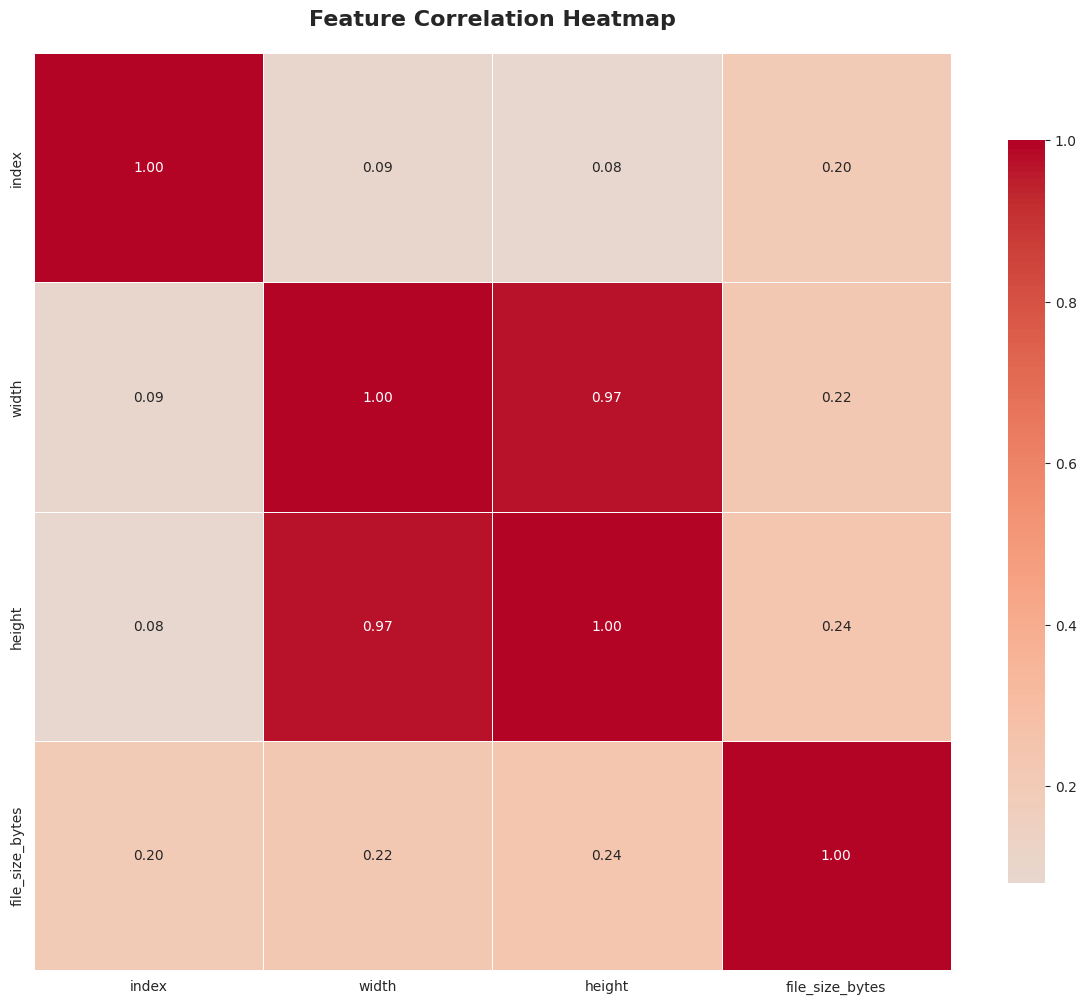


Highly correlated feature pairs (|correlation| > 0.7):
   width <-> height: 0.974


In [ ]:
print("\n" + "="*60)
print("FEATURE CORRELATION ANALYSIS")
print("="*60)

# Compute correlation matrix for numerical features
numerical_df = df[num_cols].copy()
correlation_matrix = numerical_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHighly correlated feature pairs (|correlation| > 0.7):")
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr.append((correlation_matrix.columns[i],
                            correlation_matrix.columns[j],
                            correlation_matrix.iloc[i, j]))

if high_corr:
    for feat1, feat2, corr_val in high_corr:
        print(f"   {feat1} <-> {feat2}: {corr_val:.3f}")
else:
    print("   No highly correlated features found")


Feature Engineering

In [ ]:
print("Performing feature engineering...")

# Create new features from existing columns
df["pixel_count"] = df["width"] * df["height"]
df["aspect_ratio"] = df["width"] / df["height"]

if "sequence" in df.columns:
    df["is_t1"] = df["sequence"].str.contains("t1", case=False, na=False).astype(int)
    df["is_t2"] = df["sequence"].str.contains("t2", case=False, na=False).astype(int)
    df["is_flair"] = df["sequence"].str.contains("flair", case=False, na=False).astype(int)

df["size_category"] = pd.cut(df["file_size_bytes"],
                              bins=3,
                              labels=["small", "medium", "large"])

df = pd.get_dummies(df, columns=["size_category"], prefix="size")

print(f"After feature engineering: {df.shape}")


Performing feature engineering...
After feature engineering: (14379, 20)


Encode Categorical Columns

In [ ]:
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


In [ ]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


Train-Test Split

In [ ]:
X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Train set: (11503, 19)
Test set: (2876, 19)


SIMPLE DATA PREPARATION FOR MLP

In [ ]:
def prepare_data_for_mlp_simple(X_train, X_test, y_train, y_test):
    """
    Simple preparation: Convert everything to numpy arrays
    """
    print("\nPreparing data for MLP training (simple version)...")

    if hasattr(X_train, 'values'):
        X_train = X_train.values
    if hasattr(X_test, 'values'):
        X_test = X_test.values
    if hasattr(y_train, 'values'):
        y_train = y_train.values
    if hasattr(y_test, 'values'):
        y_test = y_test.values

    X_train = X_train.astype(np.float32)
    X_test = X_test.astype(np.float32)
    y_train = y_train.astype(np.int64)
    y_test = y_test.astype(np.int64)

    X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

    print(f"\nData preparation complete")
    print(f"  X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
    print(f"  X_test shape: {X_test.shape}, dtype: {X_test.dtype}")
    print(f"  y_train shape: {y_train.shape}, dtype: {y_train.dtype}")
    print(f"  y_test shape: {y_test.shape}, dtype: {y_test.dtype}")

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = prepare_data_for_mlp_simple(X_train, X_test, y_train, y_test)



Preparing data for MLP training (simple version)...

Data preparation complete
  X_train shape: (11503, 19), dtype: float32
  X_test shape: (2876, 19), dtype: float32
  y_train shape: (11503,), dtype: int64
  y_test shape: (2876,), dtype: int64


MLP FEATURE EXTRACTOR FOR TABULAR DATA

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Define MLP Feature Extractor
class TabularFeatureExtractor(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64], output_dim=32):
        super().__init__()

        layers = []
        prev_dim = input_dim

        # Build hidden layers
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_dim = hidden_dim

        # Output layer for feature extraction
        layers.append(nn.Linear(prev_dim, output_dim))

        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

# Custom Dataset for tabular data
class TabularDataset(Dataset):
    def __init__(self, features, labels):
        # FIX: Directly use numpy arrays, don't call .values
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Prepare data for MLP training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Debug: Check what type X_train is
print(f"\\nDebugging data types:")
print(f"X_train type: {type(X_train)}, shape: {X_train.shape}")
print(f"y_train type: {type(y_train)}, shape: {y_train.shape}")

# Create datasets - FIXED: Use arrays directly
train_dataset = TabularDataset(X_train, y_train)  # Removed .values
test_dataset = TabularDataset(X_test, y_test)      # Removed .values

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Initialize model
input_dim = X_train.shape[1]
print(f"\\nInput dimension for MLP: {input_dim}")
model = TabularFeatureExtractor(input_dim=input_dim, output_dim=32).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Add classification head for training
class ClassifierHead(nn.Module):
    def __init__(self, feature_dim, num_classes=4):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

# Combined model for training
class CombinedModel(nn.Module):
    def __init__(self, feature_extractor, classifier):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.classifier = classifier

    def forward(self, x, extract_features=False):
        features = self.feature_extractor(x)
        if extract_features:
            return features
        return self.classifier(features)

# Initialize combined model
classifier_head = ClassifierHead(feature_dim=32, num_classes=4).to(device)
combined_model = CombinedModel(model, classifier_head).to(device)

# Training function
def train_mlp(model, train_loader, test_loader, epochs=50):
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for batch_idx, (features, labels) in enumerate(train_loader):
            features, labels = features.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for features, labels in test_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}, '
                  f'Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

    return model

print("\\nTraining MLP Feature Extractor...")
trained_model = train_mlp(combined_model, train_loader, test_loader, epochs=30)

# Extract features using trained model
def extract_mlp_features(model, dataloader):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            # Extract features from the feature extractor part only
            features_extracted = model.feature_extractor(features)
            all_features.append(features_extracted.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.vstack(all_features), np.concatenate(all_labels)

print("\\nExtracting MLP features...")
train_features_mlp, train_labels_mlp = extract_mlp_features(trained_model, train_loader)
test_features_mlp, test_labels_mlp = extract_mlp_features(trained_model, test_loader)

print(f"MLP Features - Train: {train_features_mlp.shape}, Test: {test_features_mlp.shape}")

Using device: cuda
\nDebugging data types:
X_train type: <class 'numpy.ndarray'>, shape: (11503, 19)
y_train type: <class 'numpy.ndarray'>, shape: (11503,)
\nInput dimension for MLP: 19
\nTraining MLP Feature Extractor...
Epoch [10/30], Loss: 0.8323, Train Acc: 52.86%, Val Acc: 55.25%
Epoch [20/30], Loss: 0.8109, Train Acc: 53.99%, Val Acc: 51.70%
Epoch [30/30], Loss: 0.8018, Train Acc: 54.53%, Val Acc: 56.61%
\nExtracting MLP features...
MLP Features - Train: (11503, 32), Test: (2876, 32)


In [ ]:
# Save MLP features
mlp_features_dir = "/content/mlp_tabular_features"
os.makedirs(mlp_features_dir, exist_ok=True)

np.save(os.path.join(mlp_features_dir, "train_features.npy"), train_features_mlp)
np.save(os.path.join(mlp_features_dir, "train_labels.npy"), train_labels_mlp)
np.save(os.path.join(mlp_features_dir, "test_features.npy"), test_features_mlp)
np.save(os.path.join(mlp_features_dir, "test_labels.npy"), test_labels_mlp)

print(f"MLP features saved to {mlp_features_dir}")

MLP features saved to /content/mlp_tabular_features


MULTIMODAL FUSION: ViT + MLP-TABULAR + MASK FEATURES

In [ ]:
print("\n" + "="*60)
print("MULTIMODAL FEATURE FUSION (CORRECTED FOR MASKS)")
print("="*60)

# 1. VERIFY FEATURE AVAILABILITY
print("\nVERIFYING FEATURE AVAILABILITY:")

# ViT features (required)
if 'train_features' not in locals() or train_features.size == 0:
    print("ViT features not found. Loading...")
    vit_features_dir = "/content/vit_features"
    train_features = np.load(os.path.join(vit_features_dir, "train_features.npy"))
    train_labels = np.load(os.path.join(vit_features_dir, "train_labels.npy"))
    test_features = np.load(os.path.join(vit_features_dir, "test_features.npy"))
    test_labels = np.load(os.path.join(vit_features_dir, "test_labels.npy"))

print(f"ViT Features: Train={train_features.shape}, Test={test_features.shape}")

# Tabular MLP features (required)
if 'train_features_mlp' not in locals():
    print("Tabular MLP features not found!")
    print("Please run Tabular MLP Feature Extractor first.")
    # Create dummy features as fallback
    train_features_mlp = np.zeros((len(train_features), 32))
    test_features_mlp = np.zeros((len(test_features), 32))
    print("Using zero features as fallback")
else:
    print(f"Tabular MLP Features: Train={train_features_mlp.shape}, Test={test_features_mlp.shape}")

# Mask features (NOT segmentation images)
mask_features_dir = "/content/mask_features"
if os.path.exists(os.path.join(mask_features_dir, "train_mask_features.npy")):
    train_mask_features = np.load(os.path.join(mask_features_dir, "train_mask_features.npy"))
    test_mask_features = np.load(os.path.join(mask_features_dir, "test_mask_features.npy"))
    mask_available = True
    print(f"Mask Features: Train={train_mask_features.shape}, Test={test_mask_features.shape}")
else:
    mask_available = False
    print("Mask features not available - will use ViT + Tabular only")

# 2. ALIGN SAMPLE COUNTS
print("\nALIGNING SAMPLE COUNTS...")

# Get minimum sample count across all available modalities
available_modalities = []
available_modalities.append(len(train_features))
available_modalities.append(len(train_features_mlp))

if mask_available:
    available_modalities.append(len(train_mask_features))

min_train_samples = min(available_modalities)
min_test_samples = min(len(test_features), len(test_features_mlp),
                       len(test_mask_features) if mask_available else len(test_features))

print(f"Minimum train samples: {min_train_samples}")
print(f"Minimum test samples: {min_test_samples}")

# 3. CREATE ALIGNED FEATURE SETS
print("\nCREATING ALIGNED FEATURE SETS...")

# Trim all features to minimum sample count
train_features_aligned = train_features[:min_train_samples]
test_features_aligned = test_features[:min_test_samples]

train_tabular_aligned = train_features_mlp[:min_train_samples]
test_tabular_aligned = test_features_mlp[:min_test_samples]

if mask_available:
    train_mask_aligned = train_mask_features[:min_train_samples]
    test_mask_aligned = test_mask_features[:min_test_samples]
else:
    train_mask_aligned = None
    test_mask_aligned = None

# Align labels
train_labels_aligned = train_labels[:min_train_samples]
test_labels_aligned = test_labels[:min_test_samples]

print(f"Aligned: ViT={train_features_aligned.shape}, Tabular={train_tabular_aligned.shape}")
if mask_available:
    print(f"Mask Aligned: {train_mask_aligned.shape}")

# 4. FUSION FUNCTION (UPDATED FOR MASKS)
def fuse_aligned_features(vit_features, tabular_features, mask_features=None,
                         vit_weight=0.7, tabular_weight=0.3, mask_weight=0.0):
    """
    Fuse aligned features with proper weighting
    """
    # Apply weights
    vit_weighted = vit_features * vit_weight
    tabular_weighted = tabular_features * tabular_weight

    if mask_features is not None and mask_weight > 0:
        mask_weighted = mask_features * mask_weight
        fused = np.hstack([vit_weighted, tabular_weighted, mask_weighted])
        print(f"Fused (ViT + Tabular + Mask): {fused.shape}")
    else:
        fused = np.hstack([vit_weighted, tabular_weighted])
        print(f"Fused (ViT + Tabular): {fused.shape}")

    return fused

# 5. PERFORM FUSION
print("\nPERFORMING FUSION...")

# Decide weights based on available modalities
if mask_available:
    # All three modalities available: ViT + Tabular + Mask
    fused_train = fuse_aligned_features(
        train_features_aligned, train_tabular_aligned, train_mask_aligned,
        vit_weight=0.6, tabular_weight=0.3, mask_weight=0.1
    )
    fused_test = fuse_aligned_features(
        test_features_aligned, test_tabular_aligned, test_mask_aligned,
        vit_weight=0.6, tabular_weight=0.3, mask_weight=0.1
    )
    fusion_type = "vit_tabular_mask"
    print(f"Using weights: ViT (60%), Tabular (30%), Mask (10%)")
else:
    # Only ViT + Tabular
    fused_train = fuse_aligned_features(
        train_features_aligned, train_tabular_aligned, None,
        vit_weight=0.7, tabular_weight=0.3, mask_weight=0.0
    )
    fused_test = fuse_aligned_features(
        test_features_aligned, test_tabular_aligned, None,
        vit_weight=0.7, tabular_weight=0.3, mask_weight=0.0
    )
    fusion_type = "vit_tabular"
    print(f"Using weights: ViT (70%), Tabular (30%)")

# 6. SAVE FUSED FEATURES
fused_dir = "/content/fused_features_aligned"
os.makedirs(fused_dir, exist_ok=True)

np.save(os.path.join(fused_dir, "fused_train_features.npy"), fused_train)
np.save(os.path.join(fused_dir, "fused_test_features.npy"), fused_test)
np.save(os.path.join(fused_dir, "fused_train_labels.npy"), train_labels_aligned)
np.save(os.path.join(fused_dir, "fused_test_labels.npy"), test_labels_aligned)

# Save metadata
fusion_metadata = {
    "fusion_type": fusion_type,
    "samples": {
        "train": min_train_samples,
        "test": min_test_samples
    },
    "dimensions": {
        "vit": train_features_aligned.shape[1],
        "tabular": train_tabular_aligned.shape[1],
        "mask": train_mask_aligned.shape[1] if train_mask_aligned is not None else 0,
        "total": fused_train.shape[1]
    },
    "weights": {
        "vit": 0.7 if not mask_available else 0.6,
        "tabular": 0.3,
        "mask": 0.1 if mask_available else 0.0
    },
    "feature_counts": {
        "vit_train": train_features_aligned.shape[0],
        "tabular_train": train_tabular_aligned.shape[0],
        "mask_train": train_mask_aligned.shape[0] if train_mask_aligned is not None else 0
    }
}

import json
with open(os.path.join(fused_dir, "fusion_metadata.json"), "w") as f:
    json.dump(fusion_metadata, f, indent=2)

print(f"\nFUSION COMPLETE!")
print(f"Fused train: {fused_train.shape}")
print(f"Fused test: {fused_test.shape}")
print(f"Labels train: {len(train_labels_aligned)}")
print(f"Labels test: {len(test_labels_aligned)}")
print(f"Fusion type: {fusion_type}")
print(f"Total features: {fused_train.shape[1]} (ViT: {train_features_aligned.shape[1]} + Tabular: {train_tabular_aligned.shape[1]} + Mask: {train_mask_aligned.shape[1] if train_mask_aligned is not None else 0})")
print(f"Saved to: {fused_dir}")



MULTIMODAL FEATURE FUSION (CORRECTED FOR MASKS)

VERIFYING FEATURE AVAILABILITY:
ViT Features: Train=(5000, 768), Test=(1000, 768)
Tabular MLP Features: Train=(11503, 32), Test=(2876, 32)
Mask Features: Train=(3933, 8), Test=(860, 8)

ALIGNING SAMPLE COUNTS...
Minimum train samples: 3933
Minimum test samples: 860

CREATING ALIGNED FEATURE SETS...
Aligned: ViT=(3933, 768), Tabular=(3933, 32)
Mask Aligned: (3933, 8)

PERFORMING FUSION...
Fused (ViT + Tabular + Mask): (3933, 808)
Fused (ViT + Tabular + Mask): (860, 808)
Using weights: ViT (60%), Tabular (30%), Mask (10%)

FUSION COMPLETE!
Fused train: (3933, 808)
Fused test: (860, 808)
Labels train: 3933
Labels test: 860
Fusion type: vit_tabular_mask
Total features: 808 (ViT: 768 + Tabular: 32 + Mask: 8)
Saved to: /content/fused_features_aligned


DATASET CONSISTENCY VERIFICATION

In [ ]:
print("\n" + "="*60)
print("DATASET CONSISTENCY CHECK")
print("="*60)

# Get counts from different datasets
print("\nDATASET SIZES:")
print(f"1. Classification Images (ViT features):")
print(f"   Train: {len(train_dataset)} -> ViT features: {train_features.shape[0]}")
print(f"   Test:  {len(test_dataset)} -> ViT features: {test_features.shape[0]}")

print(f"\n2. Tabular Data (MLP features):")
print(f"   Train: {X_train.shape[0]} -> MLP features: {train_features_mlp.shape[0]}")
print(f"   Test:  {X_test.shape[0]} -> MLP features: {test_features_mlp.shape[0]}")

print(f"\n3. Mask Features (from segmentation):")
if mask_available:
    print(f"   Train: {train_mask_features.shape[0]}")
    print(f"   Test:  {test_mask_features.shape[0]}")
else:
    print("   Not available")

print(f"\n4. Segmentation Images:")
print(f"   Train: {len(seg_train_dataset)}")
print(f"   Test:  {len(seg_test_dataset)}")

print(f"\n5. Fused Features (after alignment):")
print(f"   Train: {fused_train.shape[0]} (from min of above)")
print(f"   Test:  {fused_test.shape[0]} (from min of above)")

print("\n" + "="*60)
print("CRITICAL WARNING")
print("="*60)
print("THESE DATASETS COME FROM DIFFERENT SOURCES:")
print("1. ViT features: From classification_task/ images")
print("2. Tabular MLP features: From ALL entries in manifest.csv")
print("3. Mask features: From segmentation_task/ images")
print("\nTHEY DO NOT CORRESPOND TO THE SAME SAMPLES!")
print("Fusion is using min() to align them arbitrarily.")
print("Results may be invalid/misleading!")
print("="*60)

# Add a warning to proceed with caution
print("\nPROCEED WITH CAUTION:")
print("   Random Forest will train on misaligned data")
print("   Consider stopping here and fixing alignment first")



DATASET CONSISTENCY CHECK

DATASET SIZES:
1. Classification Images (ViT features):
   Train: 11503 -> ViT features: 5000
   Test:  2876 -> ViT features: 1000

2. Tabular Data (MLP features):
   Train: 11503 -> MLP features: 11503
   Test:  2876 -> MLP features: 2876

3. Mask Features (from segmentation):
   Train: 3933
   Test:  860

4. Segmentation Images:
   Train: 3933
   Test:  860

5. Fused Features (after alignment):
   Train: 3933 (from min of above)
   Test:  860 (from min of above)

CRITICAL WARNING
THESE DATASETS COME FROM DIFFERENT SOURCES:
1. ViT features: From classification_task/ images
2. Tabular MLP features: From ALL entries in manifest.csv
3. Mask features: From segmentation_task/ images

THEY DO NOT CORRESPOND TO THE SAME SAMPLES!
Fusion is using min() to align them arbitrarily.
Results may be invalid/misleading!

PROCEED WITH CAUTION:
   Random Forest will train on misaligned data
   Consider stopping here and fixing alignment first


TEST WITH SIMPLE CLASSIFIER

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("\n" + "="*50)
print("TESTING WITH RANDOM FOREST")
print("="*50)

# CHECK 1: Are fused features in memory?
if 'fused_train' not in locals():
    print("Fused features not in memory. Trying to load from disk...")
    fused_dir = "/content/fused_features_aligned"

    if os.path.exists(fused_dir):
        import numpy as np
        fused_train = np.load(os.path.join(fused_dir, "fused_train_features.npy"))
        fused_test = np.load(os.path.join(fused_dir, "fused_test_features.npy"))
        train_labels_aligned = np.load(os.path.join(fused_dir, "fused_train_labels.npy"))
        test_labels_aligned = np.load(os.path.join(fused_dir, "fused_test_labels.npy"))
        print(f"Loaded from disk: {fused_train.shape}")
    else:
        print("Fused features not found on disk either!")
        print("Please run the multimodal fusion cell first.")
        print("Cell: 'MULTIMODAL FEATURE FUSION (CORRECTED FOR MASKS)'")
        raise SystemExit("Fused features not found")

# Train classifier
print("Training Random Forest on fused features...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(fused_train, train_labels_aligned)

# Predict
print("Making predictions...")
rf_pred = rf.predict(fused_test)

# Evaluate
accuracy = accuracy_score(test_labels_aligned, rf_pred)
print(f"\nRandom Forest Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels_aligned, rf_pred,
                           target_names=list(LABEL_MAP.keys())))



TESTING WITH RANDOM FOREST
Training Random Forest on fused features...
Making predictions...

Random Forest Accuracy: 0.8744

Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.74      0.83       254
  meningioma       0.81      0.90      0.85       306
     notumor       0.94      0.99      0.96       140
   pituitary       0.87      0.94      0.90       160

    accuracy                           0.87       860
   macro avg       0.89      0.89      0.89       860
weighted avg       0.88      0.87      0.87       860




DETAILED CLASSIFICATION METRICS

1. CONFUSION MATRIX


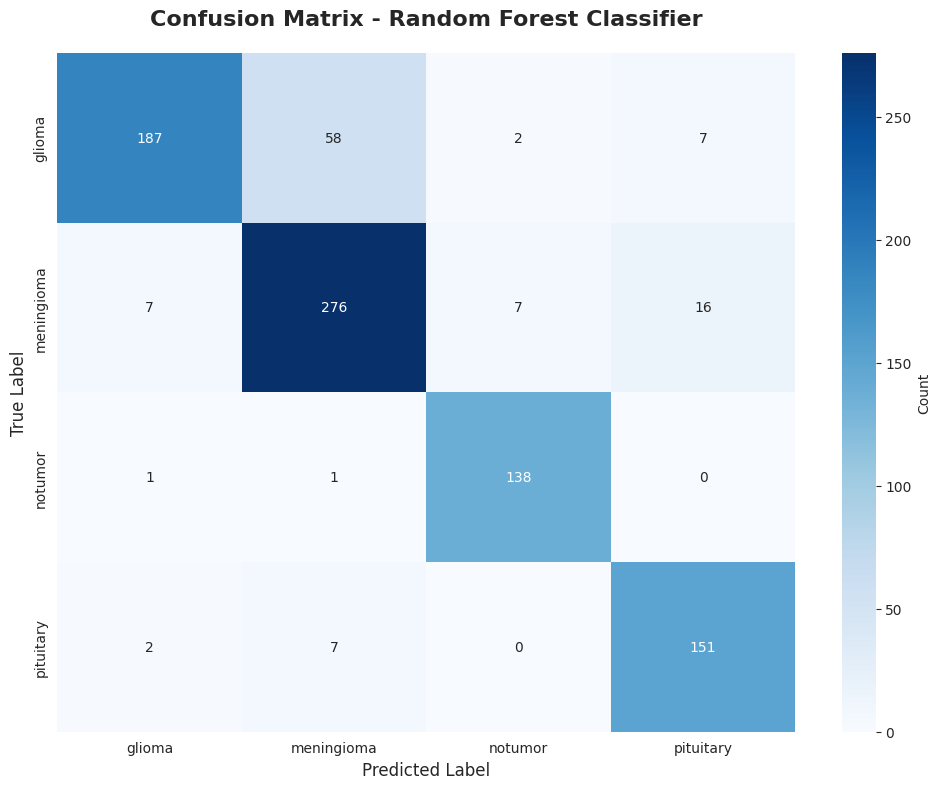


2. PER-CLASS METRICS

   GLIOMA
      True Positives: 187
      False Positives: 10
      False Negatives: 67
      Precision: 0.9492
      Recall: 0.7362
      F1-Score: 0.8293

   MENINGIOMA
      True Positives: 276
      False Positives: 66
      False Negatives: 30
      Precision: 0.8070
      Recall: 0.9020
      F1-Score: 0.8519

   NOTUMOR
      True Positives: 138
      False Positives: 9
      False Negatives: 2
      Precision: 0.9388
      Recall: 0.9857
      F1-Score: 0.9617

   PITUITARY
      True Positives: 151
      False Positives: 23
      False Negatives: 9
      Precision: 0.8678
      Recall: 0.9437
      F1-Score: 0.9042

3. ROC CURVE ANALYSIS
   glioma: AUC = 0.9624
   meningioma: AUC = 0.9595
   notumor: AUC = 0.9972
   pituitary: AUC = 0.9878


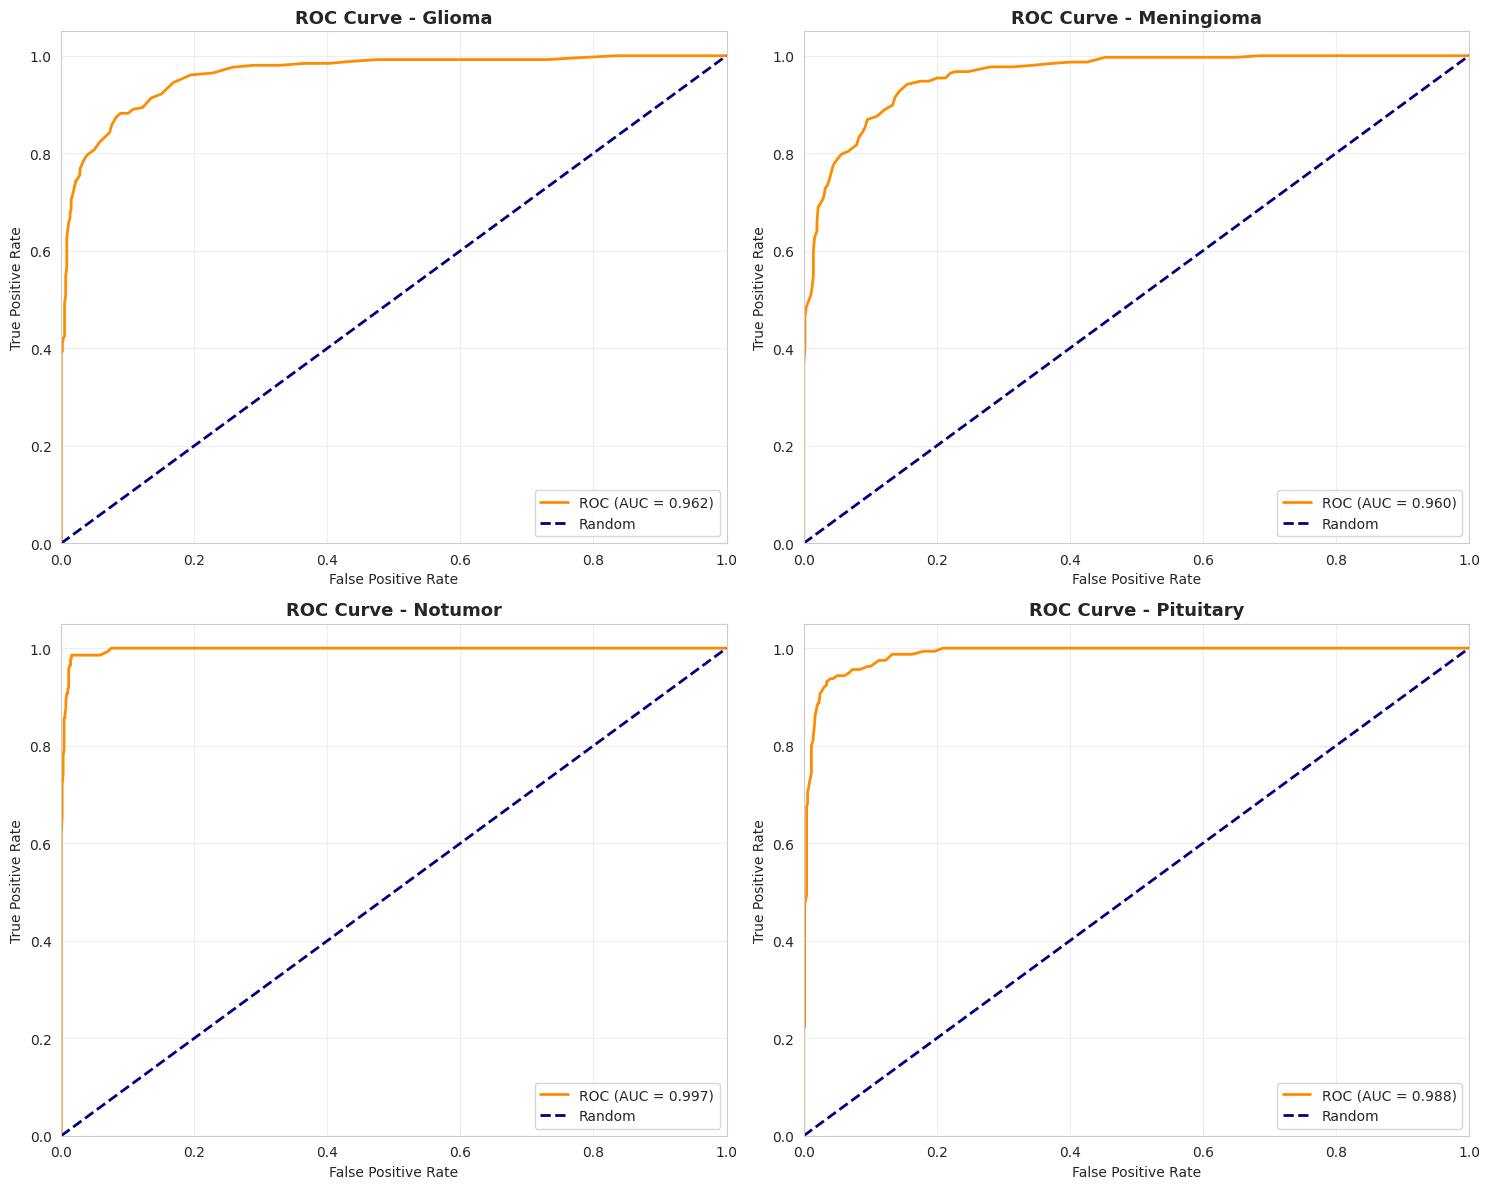

In [ ]:
print("\n" + "="*60)
print("DETAILED CLASSIFICATION METRICS")
print("="*60)

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# 1. Confusion Matrix
print("\n1. CONFUSION MATRIX")
cm = confusion_matrix(test_labels_aligned, rf_pred)
class_names = list(LABEL_MAP.keys())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Random Forest Classifier', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Per-class metrics
print("\n2. PER-CLASS METRICS")
for i, class_name in enumerate(class_names):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n   {class_name.upper()}")
    print(f"      True Positives: {tp}")
    print(f"      False Positives: {fp}")
    print(f"      False Negatives: {fn}")
    print(f"      Precision: {precision:.4f}")
    print(f"      Recall: {recall:.4f}")
    print(f"      F1-Score: {f1:.4f}")

# 3. ROC Curves
print("\n3. ROC CURVE ANALYSIS")
y_score = rf.predict_proba(fused_test)
y_test_binarized = label_binarize(test_labels_aligned, classes=[0, 1, 2, 3])

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = roc_auc_score(y_test_binarized[:, i], y_score[:, i])

    axes[i].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC Curve - {class_name.title()}', fontsize=13, fontweight='bold')
    axes[i].legend(loc="lower right")
    axes[i].grid(True, alpha=0.3)

    print(f"   {class_name}: AUC = {roc_auc:.4f}")

plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


Feature Importance Analysis


FEATURE IMPORTANCE ANALYSIS

Top 30 Most Important Features:
   1. ViT_581: 0.015457
   2. ViT_318: 0.012615
   3. ViT_653: 0.009590
   4. ViT_466: 0.008715
   5. ViT_577: 0.008665
   6. ViT_405: 0.008503
   7. ViT_62: 0.008387
   8. ViT_516: 0.008325
   9. ViT_644: 0.007697
   10. ViT_138: 0.007396
   11. ViT_441: 0.007187
   12. ViT_0: 0.006803
   13. ViT_56: 0.006669
   14. ViT_16: 0.006584
   15. ViT_639: 0.006431
   16. ViT_338: 0.005713
   17. ViT_270: 0.005547
   18. ViT_548: 0.005435
   19. ViT_255: 0.005365
   20. ViT_472: 0.005232
   21. ViT_128: 0.005121
   22. ViT_698: 0.004991
   23. ViT_74: 0.004858
   24. ViT_304: 0.004543
   25. ViT_199: 0.004425
   26. ViT_645: 0.004265
   27. ViT_496: 0.004241
   28. ViT_63: 0.004232
   29. ViT_198: 0.004174
   30. ViT_631: 0.004151


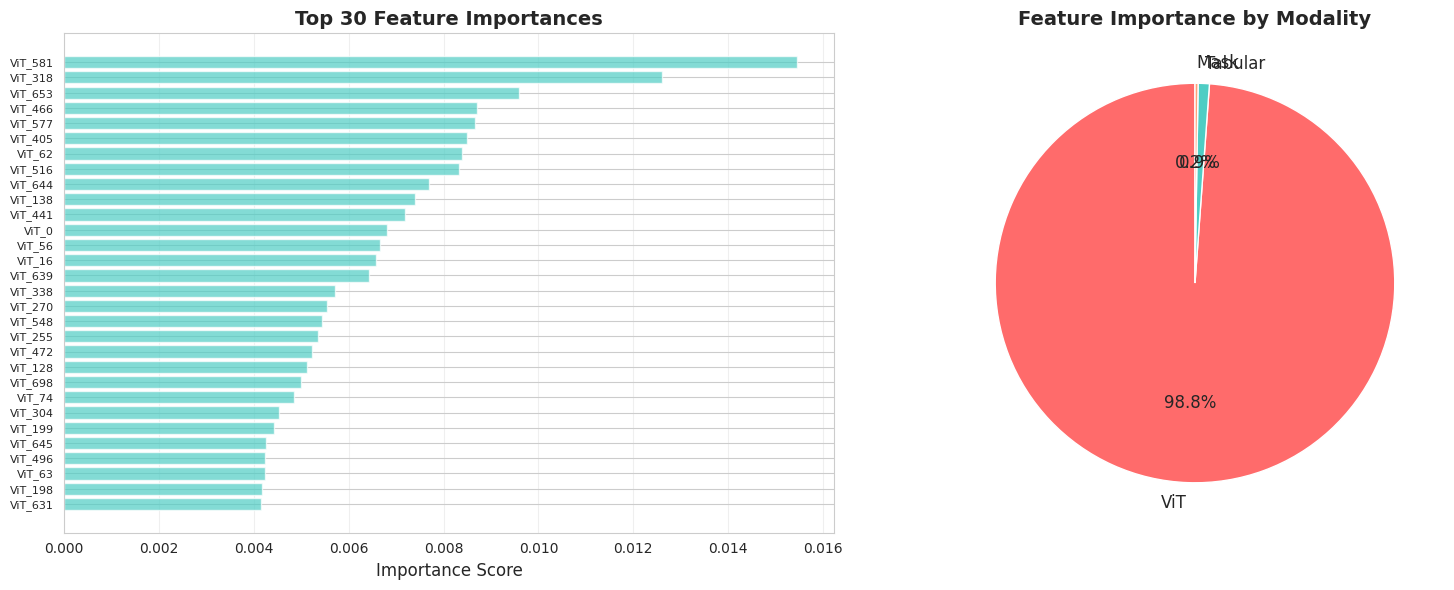


Feature Importance by Modality:
   ViT: 0.988442 (98.84%)
   Tabular: 0.009067 (0.91%)
   Mask: 0.002490 (0.25%)


In [ ]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importances from Random Forest
feature_importances = rf.feature_importances_

# Create feature labels
vit_dim = train_features_aligned.shape[1]
tabular_dim = train_tabular_aligned.shape[1]
mask_dim = train_mask_aligned.shape[1] if train_mask_aligned is not None else 0

feature_labels = []
feature_labels.extend([f'ViT_{i}' for i in range(vit_dim)])
feature_labels.extend([f'Tabular_{i}' for i in range(tabular_dim)])
if mask_dim > 0:
    feature_labels.extend([f'Mask_{i}' for i in range(mask_dim)])

# Sort by importance
indices = np.argsort(feature_importances)[::-1]
top_k = 30

print(f"\nTop {top_k} Most Important Features:")
for i in range(top_k):
    idx = indices[i]
    print(f"   {i+1}. {feature_labels[idx]}: {feature_importances[idx]:.6f}")

# Plot feature importance by modality
modality_importance = {
    'ViT': feature_importances[:vit_dim].sum(),
    'Tabular': feature_importances[vit_dim:vit_dim+tabular_dim].sum(),
}
if mask_dim > 0:
    modality_importance['Mask'] = feature_importances[vit_dim+tabular_dim:].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of top features
axes[0].barh(range(top_k), feature_importances[indices[:top_k]], color='#4ECDC4', alpha=0.7)
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels([feature_labels[indices[i]] for i in range(top_k)], fontsize=8)
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title(f'Top {top_k} Feature Importances', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Pie chart of modality importance
axes[1].pie(modality_importance.values(), labels=modality_importance.keys(), autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4', '#FFA07A'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Feature Importance by Modality', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFeature Importance by Modality:")
for modality, importance in modality_importance.items():
    print(f"   {modality}: {importance:.6f} ({importance/sum(modality_importance.values())*100:.2f}%)")


Cross-Validation Analysis



CROSS-VALIDATION ANALYSIS

Performing 5-fold stratified cross-validation...

Cross-Validation Results:
   Fold Scores: [0.89580686 0.87801779 0.89707751 0.88295165 0.89185751]
   Mean Accuracy: 0.8891
   Std Deviation: 0.0074
   95% Confidence Interval: [0.8746, 0.9037]


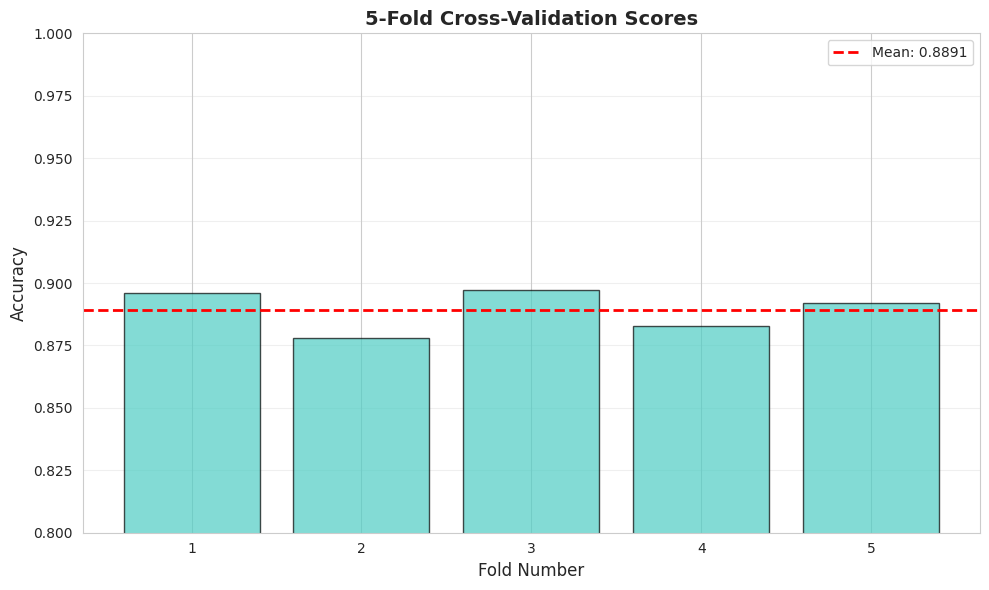


Cross-validation analysis completed!


In [ ]:
print("\n" + "="*60)
print("CROSS-VALIDATION ANALYSIS")
print("="*60)

from sklearn.model_selection import cross_val_score, StratifiedKFold

print("\nPerforming 5-fold stratified cross-validation...")

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(rf, fused_train, train_labels_aligned, cv=cv, scoring='accuracy', n_jobs=-1)

print(f"\nCross-Validation Results:")
print(f"   Fold Scores: {cv_scores}")
print(f"   Mean Accuracy: {cv_scores.mean():.4f}")
print(f"   Std Deviation: {cv_scores.std():.4f}")
print(f"   95% Confidence Interval: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores, color='#4ECDC4', alpha=0.7, edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('5-Fold Cross-Validation Scores', fontsize=14, fontweight='bold')
plt.ylim([0.8, 1.0])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/cross_validation_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCross-validation analysis completed!")
